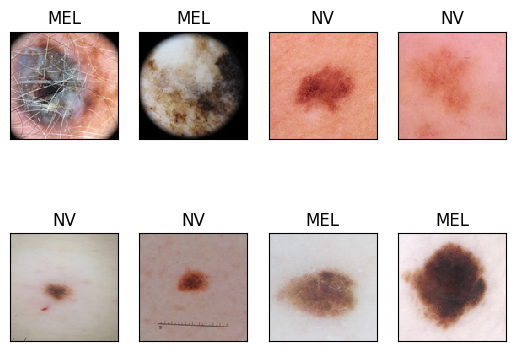

In [9]:
import torchvision
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

folder = ImageFolder('train', transform=torchvision.transforms.ToTensor())
loader = DataLoader(folder, batch_size=8, shuffle=True)

Xexamples, Yexamples = next(iter(loader))

for i in range(8):
    plt.subplot(2,4,i+1)  
    img = Xexamples[i].numpy().transpose(1, 2, 0)    
    plt.imshow(img, interpolation='none')
    plt.title('NV' if Yexamples[i] else 'MEL')
    plt.xticks([])
    plt.yticks([])


Baseline CNN

In [10]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Adding batchnormalization

In [11]:
import torch
import torch.nn as nn


class BatchNormCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BatchNormCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # If input image size is 224x224:
            # 224 -> 112 -> 56 -> 28 after pooling
            nn.Linear(128 * 28 * 28, 256),

            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Data augmentation

In [12]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ResidualBlock

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.block(x)
        out += identity
        out = self.relu(out)
        return out

Transfer Learning

In [14]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final classifier
model.fc = nn.Linear(model.fc.in_features, 2)

In [15]:
for param in model.parameters():
    param.requires_grad = True

    optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    return total_loss / len(loader), accuracy



In [ ]:


# =========================================================
# RUN BASELINE MODEL
# =========================================================

baseline_model = BaselineCNN(num_classes=2).to(device)

baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

# Train baseline
epochs = 10

for epoch in range(epochs):

    baseline_model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        baseline_optimizer.zero_grad()

        outputs = baseline_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        baseline_optimizer.step()

# Evaluate baseline
baseline_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = baseline_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

baseline_accuracy = correct / total

print("Baseline Accuracy:", baseline_accuracy)

# =========================================================
# RUN YOUR MODEL (RESNET18)
# =========================================================

my_model = transfer_model.to(device)

my_optimizer = optim.Adam(
    my_model.parameters(),
    lr=1e-4
)

# Train your model
for epoch in range(epochs):

    my_model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        my_optimizer.zero_grad()

        outputs = my_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        my_optimizer.step()

# Evaluate your model
my_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = my_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

my_accuracy = correct / total

print("My Model Accuracy:", my_accuracy)

NameError: name 'device' is not defined

## Task1: Explore different solutions and evaluate on validation set

Set up a machine learning architecture for an image classifier and train it on the training set. Explore and compare different solutions and evaluate them on the validation set. You can use accuracy score as the performance metric to compare the different solutions.

INVESTEGATE: 
batch normalization,
residual connections,
data augmentation by applying random transformations Links to an external site. to the images,
transfer learning using a pre-trained model (see below for some hints).

IDEAS: 

1. ResNet
2. EfficientNet
3. DenseNet
4. Vision Transformer
5. MobileNet

## Task2: Compute the accuracy score on test set

You will receive the test set with the labels next week. Compute the accuracy score on this dataset and include it in the report.

Clarification: Since you will receive your test set result quite late, your discussions about your technical choices should be based on the validation set results. You will have just one test set score, so any comparisons between different solutions will have to be based on the validation set.

## Task3: Write a technical report

When you have investigated and compared your technical solutions, write a report detailing your implementation, your experiments and analysis.

The submitted report should be at most 4 pages (excluding ethics, limitations, and appendix). Use the following template Download template to write the report. It should be written as a conventional technical report: a typical structure would be that you have sections for the introduction, technical solutions, experiments/results, conclusion.

In addition to the standard technical sections mentioned above, you should also include two sections called Limitations and Ethical considerations respectively. This requirement is similar to what is used at some technical conferences. In Limitations, you discuss about issues that you think could be improved in your solution or that would limit its real-world usefulness. In Ethical considerations, you should discuss all ethical aspects that you think are relevant when developing and applying your solution. These sections should be placed after the conclusion and they can each be one or a couple of paragraphs. They do not count towards the page limit of 4 pages.

You are allowed to include an appendix where you can mention low-level technical details such as model layers, training hyperparameters. The appendix does not count towards the page limit.